# Density-functional theory + Downfolding

In the interest of time, we provide all of the input and output files from a converged DFT and wannierization of the Kohn-Sham bands. However, for completeness and reproducibility, this section outlines the full procedure step by step. These instructions can be used to reproduce our results or adpated to study other correlated materials in the future.

## 🧮 1. Density-functional theory with Quantum ESPRESSO

We perform an electronic structure calculation based on Kohn-Sham density-functional theory (DFT), as implemented in the plane-wave pseudopotential code [Quantum ESPRESSO](https://www.quantum-espresso.org). 

The goal of this step is to obtain the Kohn-Sham band structure and wavefunctions, which we will later downfold into a tight-binding model using Wannier functions.

#### 🔧 Quantum ESPRESSO input file

Quantum ESPRESSO input files are organized into several sections, or "cards", including ``&control``, ``&system``, and ``&electrons``, followed by structural information such as lattice vectors and atomic positions.

For this calcultion, we perform a **self-consistent field (SCF)** run (``calculation = 'scf'``), which means the DFT equations will be solved iteratively until the charge density converges.

There are many tunable parameters in a DFT calculation. However, three key settings should always be checked for convergence:

- **Plane-wave cutoff energy** :``ecutwfc`` (wavefunctions), ``ecutrho`` (charge density)
- **Brillouin zone sampling**: ``K_POINTS`` grid
- **Smearing**: important for metallic or small-gap systems to ensure smooth convergence

We start by preparing the input file for the calculation (see ``data/scf/lco.scf.in``). Below is the complete SCF input file used for La$_{2}$CuO$_{4}$:

```
&control
   calculation        = 'scf',
   restart_mode       = 'from_scratch',
   wf_collect         = .false.,
   prefix             = 'lco', 
   tstress            = .true., 
   tprnfor            = .true., 
   pseudo_dir         = '../pseudo/',
   outdir             = '../tmp/',
/ 
&system 
   ibrav              = 0,
   nat                = 7,
   ntyp               = 3,
   ecutwfc            = 55.0,
   ecutrho            = 660.0,
   occupations        = 'smearing',
   degauss            = 0.01,
   smearing           = 'm-p',
/ 
&electrons 
   conv_thr           = 1.0d-10,
   mixing_beta        = 0.7,
   mixing_mode        = 'local-TF'
   startingpot        = 'file',
/

ATOMIC_SPECIES 
   La   138.905       la_pbe_v1.uspp.F.UPF
   Cu   58.6934       cu_pbe_v1.2.uspp.F.UPF
   O    15.9994       o_pbe_v1.2.uspp.F.UPF

CELL_PARAMETERS (angstrom)
  -1.909144696   1.909144696   6.603098061
   1.909144696  -1.909144696   6.603098061
   1.909144696   1.909144696  -6.603098061

ATOMIC_POSITIONS (angstrom)
La           -0.0000000000       -0.0000000000        4.7702839137
La            1.9091446961        1.9091446961        1.8328141469
Cu           -0.0000000000       -0.0000000000       -0.0000000000
O            -0.0000000000        1.9091446961        0.0000000000
O             1.9091446961       -0.0000000000        0.0000000000
O            -0.0000000000       -0.0000000000        2.4522239552
O             1.9091446961        1.9091446961        4.1508741055

K_POINTS automatic
  7 7 7 0 0 0 
```

La$_{2}$CuO$_{4}$ crystallizes in the body-centered tetragonal K$_{2}$NiF$_{4}$ structure (space group I4/mmm), with the copper atoms forming a square lattice in the CuO$_{2}$ planes.

#### ▶️ Running the SCF calculation

Quantum ESPRESSO provides a suite of executables for performing different types of calculations. To run the SCF calculation, we use the ``pw.x`` executable. From the terminal, use one of the following commands:

```bash
pw.x < lco.scf.in | tee lco.scf.out # stream output and log to file
```
or

```bash
pw.x < lco.scf.in > lco.scf.out  # write output directly to file
```
> 💡 **Tip**: You can monitor convergence in `lco.scf.out` by tracking the total energy. For example, ``grep Energy lco.scf.out``.

## 📈 2. Band structure calculation with Quantum ESPRESSO

With the SCF calculation converged, we can now begin post-processing our results. For our purposes, we are particulary interested in the low-energy electronic structure, so inspecting the **band structure** -- the eigenvalues of the Kohn-Sham Hamiltonian along a high-symmetry paths in the Brilloun zone -- is essential.

#### ⏱️ What are we calculating?

The band structure is computed by evaluating the Kohn-Sham Hamiltonian along a **user-defined path of $k$-points** in reciprocal space. This is done in a **non-self-consistent field (NSCF)** calculation, where the charge density remains fixed (taken from the SCF run).

#### ⚙️ NSCF (bands) calculation (pw.x)

We create a modified input file (``data/bands/lco.bnd.in``) with the following key changes:

```
&control
   calculation        = 'bands',
/ 
&electrons 
   diago_full_acc     = .true.,
/

K_POINTS crystal_b
5
 0.00  0.00  0.00 50 !G
 0.25 -0.25  0.25 50 !N
 0.00  0.00  0.50 50 !X
 0.00  0.00  0.00 50 !G
 0.25  0.25 -0.25 50 !M
```
#### 🔎 Explanation of changes:

- ``calculation = 'bands'``: this tells Quantum ESPRESSO to perform a band structure calculation using the fixed charge density from the SCF step (saved in ``../tmp/``).
- ``diago_full_acc = .true.``: Ensure full diagonalization of the Kohn-Sham Hamiltonian -- no iterative or approximate solvers are used.
- ``K_POINTS crystal_b``: The $k$-points are specficed in crystal coordinates. The last integer of each line (e.g., 50) tells Quantum ESPRESSO to interpolate that many points between the current and next $k$-point.

> 💡**Note**: The Brillouin zone here corresponds to the **body-centered tetragonal** structure of La$_{2}$CuO$_{4}$ (space group I4/mmm). The high-symmetry points are chosen accordingly to reproduce the familiar two-dimensional band structure one would get from a tight-binding model on square lattice.

#### ▶️ Run the band structure calculation

```bash
pw.x < lco.bnd.in > lco.bnd.out
```
#### 🧾 Post-processing with bands.x
After the ``pw.x`` run completes, the next step is to extract and format the band structure data using the ``bands.x`` utility. We prepare a simple input file (``data/bands/lco.bands.in``) as follows:

```
&BANDS
   prefix  = 'lco',
   outdir  = '../tmp/',
   filband = 'lco_bands.dat'
/
```
This program reads the previously calculated Kohn-Sham eigenvalues and writes them to files suitable for plotting.

#### ▶️ Run the bands post-processing

```bash
bands.x < lco.bands.in > lco.bands.out
```

## 🔗 3. Quantum Espresso interfaced with Wannier90

To connect density-functional theory to DMFT, we must construct a low-energy tight-binding model Hamiltonian in a localized orbital basis. This is achieved by projecting the Kohn-Sham states onto **maximally localized Wannier functions** using Wannier90, which is tightly integrated with Quantum ESPRESSO.

Below we outline the key steps required to perform this Wannierization procedure:

#### 🧩 1: Prepare the input files
After completing a SCF run with Quantum ESPRESSO, we need to run a NSCF run on a k-mesh in the full Brilloun zone. This is what Wannier90 will use to interpolate the Wannier Hamiltonian. This is provided in ``data/mlwf/lco.nscf.in``.

#### 📝 2: Create the Wannier90 input file
For an example of the Wannier90 input file, please see ``data/mlwf/lco.win``.

#### ▶️ 3: Running the NSCF calculation
```bash
pw.x < lco.nscf.in > lco.nscf.out
```

#### 🧮 4: Run wannier90.x -pp

```bash
wannier90.x -pp lco
```

#### ⚙️ 5: Run pw2wannier90.x
```bash
pw2wannier90.x < lco.pw2wan.in > lco.pw2wan.out
```

#### 🚀 6: Run wannier90.x
```bash
wannier90.x lco
```

## 🧩 4. Exercises

Now that we have run both the **DFT** and **Wannier90 interpolation**, we are ready to compare them and build our low-energy tight-binding model. This will validate how well the low-energy tight-binding model reproduces the _ab-initio_ Kohn-Sham bands -- a key sanity check before beginning the DMFT calculation.

We'll write a Python code step-by-step to: 
1. Load and reshape the band structure data
2. Plot the band structure data
3. Load the Wannier90 data and overlay the Wannier model on the DFT bands.

Let's build the plot one step at a time:

### 🧪 Excercise 1: Load and reshape the DFT band structure data
The file ``data/bands/lco_bands.data.gnu`` contains a column of $(k, E)$ pairs. Start by loading the data and reshaping into a 2D array of shape ``(n_bands, n_kpts)``.
> 💡 **Tip**: The numpy library has a utility function ``numpy.loadtxt`` for reading text files.
>
> 💡 **Tip**: The $k$-points are repeated for each band, so you can get the unique k-points by calling ``numpy.unique``.

In [1]:
import numpy as np 

filename = 'data/bands/lco_bands.dat.gnu'

# Step 1: load the DFT data
data = np.loadtxt(filename)

# Step 2: separate the k-points and eigenvalues
kpts = np.unique(data[:,0])
bands = data[:,1].reshape(-1, len(kpts))

### 🧪 Excercise 2: Plot the DFT band structure
Use ``matplotlib`` and our custom ``matplotlib.axes`` functions (``plot_band_structure``) to visualize the DFT band structure. The band structure is defined with respect to the Fermi level, which can be obtained from ``data/scf/lco.scf.out``.

> 💡 **Tip**: Most DFT codes write lots of information to their output files, thus the unix program ``grep`` is extremely useful tool to grab quick information. For the Fermi level, you can run ``grep Fermi data/scf/lco.scf.out``

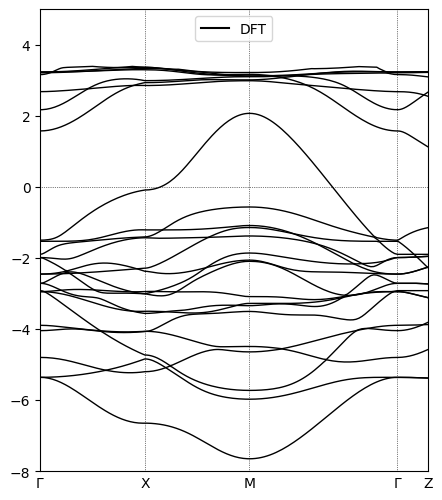

In [3]:
import matplotlib.pyplot as plt
from utils.mpl_interface import *

# Fermi level (grep Fermi data/scf/lco.scf.out)
eF =  12.7367

# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']

# create matplotlib figure
fig, ax = plt.subplots(figsize=(5,6))

# use kpts and bands from Exercise 1.1
ax.plot_band_structure(kpts, bands, fermi_level=eF, high_symm_points=high_symm_points, high_symm_labels=high_symm_labels)

ax.plot([], [], color='k', label='DFT')
ax.legend(loc='upper center', ncols=2, fontsize=10)
ax.set_ylim(-8, 5)
plt.show()

### 🧪 Excercise 3: Overlay the Wannier90 interpolated bands

Let's add the interpolated Wannier90 bands to our DFT band structure to compare. Similar to the DFT band structure, the Wannier90 bands are written to column formatted text file: ``data/mlwf/lco_band.dat``. Load and reformat the data, then use our custom matplotlib function ``plot_bands`` to plot the Wannier90 bands on top of the DFT band structure.

> 💡 **Tip**: Wannier90 uses different units so you will have to either scale the Wannier90 k-points or the DFT k-points by their ratio so that the x-axis wil match.

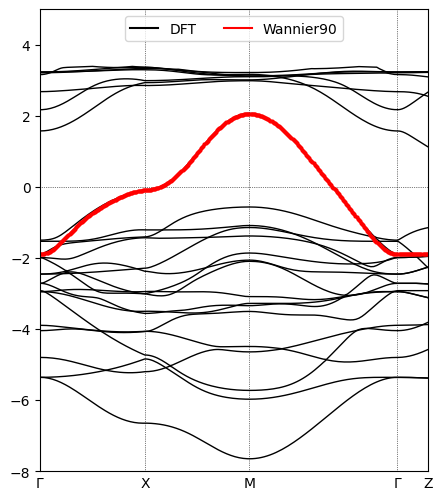

In [4]:
filename = 'data/mlwf/lco_band.dat'

# Step 1: load the Wannier90 data
w90_data = np.loadtxt(filename)
w90_kpts = np.unique(w90_data[:,0])
w90_bands = w90_data[:,1].reshape(-1, len(w90_kpts))

# Step 2: calculate scale factor
factor = kpts[-1]/w90_kpts[-1]

# Step 3: add DFT bands from Exercise 1.2
fig, ax = plt.subplots(figsize=(5,6))
ax.plot_band_structure(kpts, bands, fermi_level=eF, high_symm_points=high_symm_points, high_symm_labels=high_symm_labels)
ax.plot([], [], color='k', label='DFT')

# Step 4: add the Wannier90 bands
ax.plot_bands(w90_kpts*factor, w90_bands-eF, marker='o', ms=2, color='r')
ax.plot([], [], color='r', label='Wannier90')

ax.legend(loc='upper center', ncols=2, fontsize=10)
ax.set_ylim(-8, 5)
plt.show()

### 🧪 Excercise 4: Summarize

Let's take a moment to describe our results in a bit more detail. In a few sentences, can you describe the most salient features of the band structure of La$_{2}$CuO$_{4}$, as well as the features of our low-energy model.

The band structure of La$_{2}$CuO$_{4}$ shows a dispersive two-dimensional band derived from the Cu-$d_{x^{2}-y^{2}}$ orbital at low-energy. The overall bandwidth $W$ spans around $\sim 4$ eV. The remaining complex bands are formed from the hybridized O($2p)$ and Cu($3d$) orbitals. There are a total of 17 bands (5 Cu and 12 O).